In [1]:
import numpy as np
import os
os.makedirs("output", exist_ok=True)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.gridspec import GridSpec
from lib.plot_style import set_style_params, set_style_params_ppt
from lib.airfoil_utils import extract_data, extract_simulation_data

# define the plot style

In [2]:
# 绘图样式由 plot_style 库提供
set_style_params()
# （原 set_style_params 定义已移至 plot_style.py）

In [3]:
# set_style_params_ppt 已从 plot_style 导入，演示时调用即可


# plot the independence of airfoil data and points

In [4]:
# read data : Exp and different points
Experiment_data = pd.read_excel('data/airfoil_experiment.xlsx')
Simulation_data = pd.read_excel('data/simulation_data_step.xlsx')

# extract_data, extract_simulation_data 已从 airfoil_utils 导入

# only need Re 101k, E374
data1 = extract_data(Data=Experiment_data,Re=100900, airfoil_name="E374")
data2 = Simulation_data

## for cl

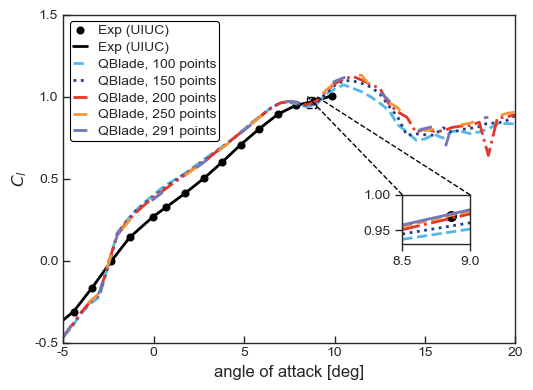

In [5]:
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True
# cl independence
fig_name = f"output/Re_{101}k_E{374}_Cl.png"
# create figure and axis objects
width, height = 1, 1
figsize = (5.51 / width, 4 / height)
fig, ax = plt.subplots(figsize=figsize) 
curve_label = "Exp (UIUC)"
# plot the curve
ax.scatter(data1['alpha'],data1['Cl'],label = 'Exp (UIUC)',color='black',s=25,marker='o')
ax.plot(data1['alpha'],data1['Cl'], linestyle='-', color='black', label=curve_label)
ax.plot(extract_simulation_data(data2,points=100)['alpha'],extract_simulation_data(data2,points=100)['Cl'],linestyle='--', color='#55B7E6', label='QBlade, 100 points')# '--' dotted line,'v' triangle marker='^',
ax.plot(extract_simulation_data(data2,points=150)['alpha'],extract_simulation_data(data2,points=150)['Cl'],linestyle=':', color='#193E8F', label='QBlade, 150 points')# '--' dotted line,'v' triangles),# '--' dotted line,'v' triangles
ax.plot(extract_simulation_data(data2,points=200)['alpha'],extract_simulation_data(data2,points=200)['Cl'],linestyle='-.', color='#E53528', label='QBlade, 200 points')# '--' dotted line,'v' triangles
ax.plot(extract_simulation_data(data2,points=250)['alpha'],extract_simulation_data(data2,points=250)['Cl'],linestyle=(0, (5, 10)), color='#F09739', label='QBlade, 250 points')# '--' dotted line,'v' triangles
ax.plot(extract_simulation_data(data2,points=291)['alpha'],extract_simulation_data(data2,points=291)['Cl'],linestyle=(0, (5, 15)), linewidth=2, color='#6F78B9', label='QBlade, 291 points')# '--' dotted line,'v' triangles
# set up the plot limits and labels
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        ax.legend(
        loc='upper left',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
        
# Creating an inset of the main plot (Zoom-in)
axins = ax.inset_axes((0.75,0.3,0.15,0.15))
x_left, x_right = 8.0, 9.5
# Zoomed-in plot, e.g., zooming in on a range of alpha and Cl
data_detail = extract_simulation_data(data2, points=100)
data_detail = data_detail[(data_detail['alpha'] < x_right) & (data_detail['alpha'] > x_left)]
axins.plot(data_detail['alpha'], data_detail['Cl'], linestyle='--', color='#55B7E6')

data_detail = extract_simulation_data(data2, points=150)
data_detail = data_detail[(data_detail['alpha'] < x_right) & (data_detail['alpha'] > x_left)]
axins.plot(data_detail['alpha'], data_detail['Cl'], linestyle=':', color='#193E8F')

data_detail = extract_simulation_data(data2, points=200)
data_detail = data_detail[(data_detail['alpha'] < x_right) & (data_detail['alpha'] > x_left)]
axins.plot(data_detail['alpha'], data_detail['Cl'], linestyle='-.', color='#E53528')

data_detail = extract_simulation_data(data2, points=250)
data_detail = data_detail[(data_detail['alpha'] < x_right) & (data_detail['alpha'] > x_left)]
axins.plot(data_detail['alpha'], data_detail['Cl'], linestyle='--', color='#F09739')

data_detail = extract_simulation_data(data2, points=291)
data_detail = data_detail[(data_detail['alpha'] < x_right) & (data_detail['alpha'] > x_left)]
axins.plot(data_detail['alpha'], data_detail['Cl'], linestyle='-', color='#6F78B9')

# Add the scatter plot of experimental data
data1= data1[(data1['alpha'] < x_right) & (data1['alpha'] > x_left)]
axins.scatter(data1['alpha'], data1['Cl'], color='black', s=50, marker='o')
    # Set the zoomed-in limits (adjust as needed)
axins.set_xlim(x_left + 0.5, x_right - 0.5)  # Zoom into a specific alpha range
axins.set_ylim(0.93, 1.0)  # Zoom into a specific Cl range
axins.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=1))
axins.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=1)) 
# Draw a rectangle on the main plot to indicate the zoomed-in region
mark_inset(ax, axins, loc1=1, loc2=2, fc="none", ec="0.01", linestyle='--', linewidth=1)

plt.tight_layout()
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', nbins=7))
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=4))

# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


## for cd

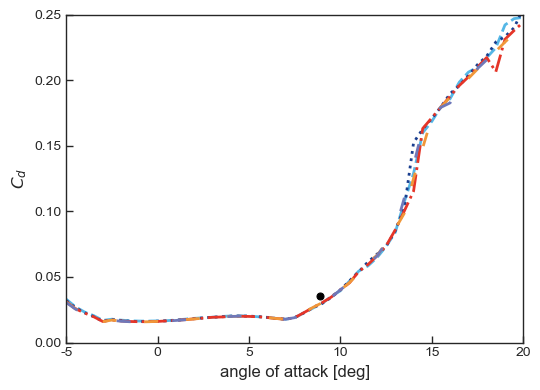

In [6]:
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0.0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
# cl independence
fig_name = f"output/Re_{101}k_E{374}_Cd.png"
# create figure and axis objects
width, height = 1, 1
figsize = (5.51 / width, 4 / height)
fig, ax = plt.subplots(figsize=figsize) 
curve_label = "Exp (UIUC)"
# plot the curve
ax.scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=25,marker='o')
ax.plot(extract_simulation_data(data2, points=100)[x], extract_simulation_data(data2, points=100)[y], linestyle='--', color='#55B7E6', label='QBlade, 100 points')
ax.plot(extract_simulation_data(data2, points=150)[x], extract_simulation_data(data2, points=150)[y], linestyle=':', color='#193E8F', label='QBlade, 150 points')
ax.plot(extract_simulation_data(data2, points=200)[x], extract_simulation_data(data2, points=200)[y], linestyle='-.', color='#E53528', label='QBlade, 200 points')
ax.plot(extract_simulation_data(data2, points=250)[x], extract_simulation_data(data2, points=250)[y], linestyle=(0, (5, 10)), color='#F09739', label='QBlade, 250 points')
ax.plot(extract_simulation_data(data2, points=291)[x], extract_simulation_data(data2, points=291)[y], linestyle=(0, (5, 15)), linewidth=2, color='#6F78B9', label='QBlade, 291 points')
# set up the plot limits and labels
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        ax.legend(
        loc='upper left',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
        
plt.tight_layout()
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', nbins=7))
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))

# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


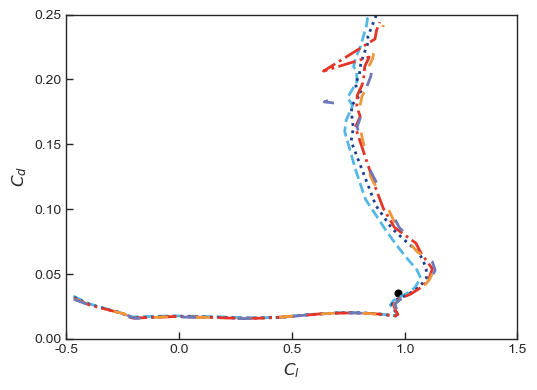

In [7]:
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0.0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True
# cl independence
fig_name = f"output/Re_{101}k_E{374}_Cd_cl.png"
# create figure and axis objects
width, height = 1, 1
figsize = (5.51 / width, 4 / height)
fig, ax = plt.subplots(figsize=figsize) 
curve_label = "Exp (UIUC)"
# plot the curve
ax.scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=25,marker='o')
ax.plot(extract_simulation_data(data2, points=100)[x], extract_simulation_data(data2, points=100)[y], linestyle='--', color='#55B7E6', label='QBlade, 100 points')
ax.plot(extract_simulation_data(data2, points=150)[x], extract_simulation_data(data2, points=150)[y], linestyle=':', color='#193E8F', label='QBlade, 150 points')
ax.plot(extract_simulation_data(data2, points=200)[x], extract_simulation_data(data2, points=200)[y], linestyle='-.', color='#E53528', label='QBlade, 200 points')
ax.plot(extract_simulation_data(data2, points=250)[x], extract_simulation_data(data2, points=250)[y], linestyle=(0, (5, 10)), color='#F09739', label='QBlade, 250 points')
ax.plot(extract_simulation_data(data2, points=291)[x], extract_simulation_data(data2, points=291)[y], linestyle=(0, (5, 15)), linewidth=2, color='#6F78B9', label='QBlade, 291 points')
# set up the plot limits and labels
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        ax.legend(
        loc='upper left',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
        
plt.tight_layout()
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True, prune='lower', nbins=7))
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=4))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))

# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


# plot the accuracy of the airfoil performance prediction model

In [8]:
# read data : Exp and Xfoil
Experiment_data = pd.read_excel('data/airfoil_experiment.xlsx')
Simulation_data = pd.read_excel('data/airfoil_simulation.xlsx')
# extract_data 已从 airfoil_utils 导入

## E374

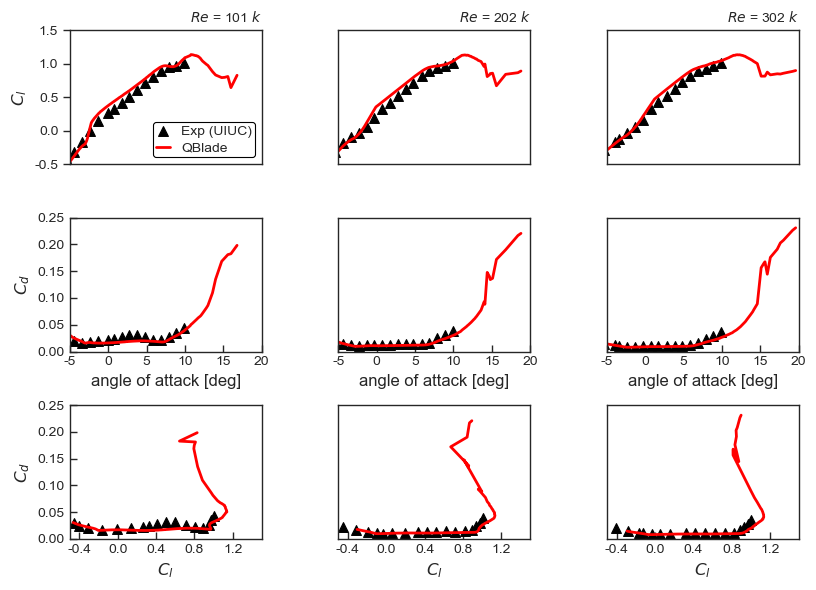

In [14]:
Re = 100900
airfoil = "E374"
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True


# create figure and axis objects
width, height = 2/3,2/3
figsize = (5.51  / width, 4 / height)
fig = plt.figure(figsize=figsize)
gs = GridSpec(nrows=3, ncols=3, figure=fig)
axs = []
axs.append(fig.add_subplot(gs[0, 0]))  # 第一行第一列
axs.append(fig.add_subplot(gs[0, 1]))  # 第一行第二列
axs.append(fig.add_subplot(gs[0, 2]))  # 第一行第三列

axs.append(fig.add_subplot(gs[1, 0]))  # 第二行第一列
axs.append(fig.add_subplot(gs[1, 1]))  # 第二行第二列
axs.append(fig.add_subplot(gs[1, 2]))  # 第二行第三列

axs.append(fig.add_subplot(gs[2, 0]))  # 第三行第一列
axs.append(fig.add_subplot(gs[2, 1]))  # 第三行第二列
axs.append(fig.add_subplot(gs[2, 2]))  # 第三行第三列


c = 0
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_xticks([])
axs[c].tick_params(axis='x', top=False)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)

# set up the label of the axis
# axs[r].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=4))




c = 3
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=5))




c = 6
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=5))



c = 1
Re = 201500
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x, y = 'alpha', 'Cl'
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 202 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='x', top=False)
axs[c].set_xticks([])
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# set up the label of the axis
# axs[r].set_xlabel(x_label)
# axs[r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )




c = 4
x, y = 'alpha', 'Cd'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 


c = 7
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  


c = 2
Re = 302200
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 302 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='x', top=False)
axs[c].set_xticks([])
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
        )




c = 5
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )

axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 



c = 8
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)

# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  



plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.4)
# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


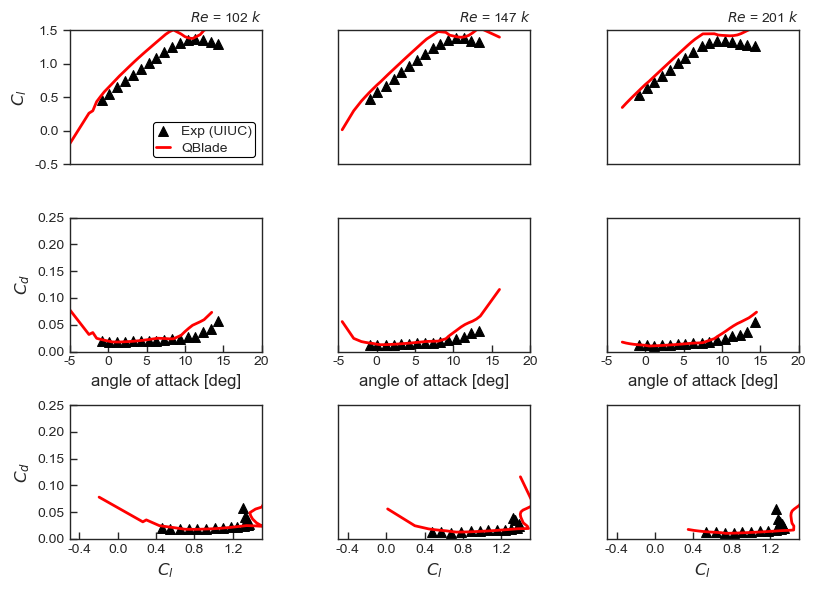

In [10]:
Re = 102600
airfoil = "NACA6409"
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True


# create figure and axis objects
width, height = 2/3,2/3
figsize = (5.51  / width, 4 / height)
fig = plt.figure(figsize=figsize)
gs = GridSpec(nrows=3, ncols=3, figure=fig)
axs = []
axs.append(fig.add_subplot(gs[0, 0]))  # 第一行第一列
axs.append(fig.add_subplot(gs[0, 1]))  # 第一行第二列
axs.append(fig.add_subplot(gs[0, 2]))  # 第一行第三列

axs.append(fig.add_subplot(gs[1, 0]))  # 第二行第一列
axs.append(fig.add_subplot(gs[1, 1]))  # 第二行第二列
axs.append(fig.add_subplot(gs[1, 2]))  # 第二行第三列

axs.append(fig.add_subplot(gs[2, 0]))  # 第三行第一列
axs.append(fig.add_subplot(gs[2, 1]))  # 第三行第二列
axs.append(fig.add_subplot(gs[2, 2]))  # 第三行第三列


c = 0
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 102 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_xticks([])
axs[c].tick_params(axis='x', top=False)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)

# set up the label of the axis
# axs[r].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=4))




c = 3
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=5))




c = 6
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=5))



c = 1
Re = 147300
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x, y = 'alpha', 'Cl'
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 147 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='x', top=False)
axs[c].set_xticks([])
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# set up the label of the axis
# axs[r].set_xlabel(x_label)
# axs[r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )




c = 4
x, y = 'alpha', 'Cd'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 


c = 7
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  


c = 2
Re = 200100
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 201 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='x', top=False)
axs[c].set_xticks([])
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
        )




c = 5
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )

axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 



c = 8
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)

# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  



plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.4)
# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


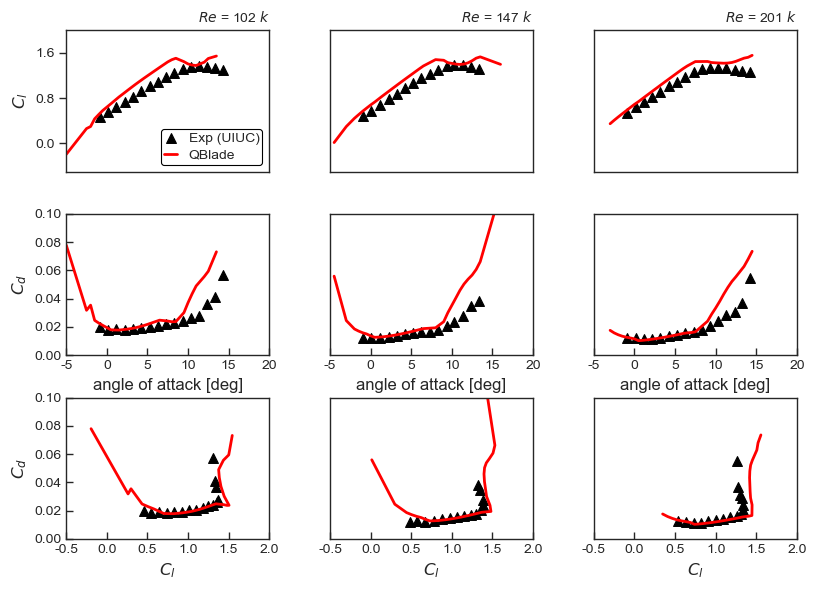

In [11]:
Re = 102600
airfoil = "NACA6409"
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 2
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True


# create figure and axis objects
width, height = 2/3,2/3
figsize = (5.51  / width, 4 / height)
fig = plt.figure(figsize=figsize)
gs = GridSpec(nrows=3, ncols=3, figure=fig)
axs = []
axs.append(fig.add_subplot(gs[0, 0]))  # 第一行第一列
axs.append(fig.add_subplot(gs[0, 1]))  # 第一行第二列
axs.append(fig.add_subplot(gs[0, 2]))  # 第一行第三列

axs.append(fig.add_subplot(gs[1, 0]))  # 第二行第一列
axs.append(fig.add_subplot(gs[1, 1]))  # 第二行第二列
axs.append(fig.add_subplot(gs[1, 2]))  # 第二行第三列

axs.append(fig.add_subplot(gs[2, 0]))  # 第三行第一列
axs.append(fig.add_subplot(gs[2, 1]))  # 第三行第二列
axs.append(fig.add_subplot(gs[2, 2]))  # 第三行第三列


c = 0
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 102 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_xticks([])
axs[c].tick_params(axis='x', top=False)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)

# set up the label of the axis
# axs[r].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=4))




c = 3
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = -0.00, 0.1
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=5))




c = 6
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 2.0
y_min,y_max = 0, 0.1
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c].yaxis.set_major_locator(MaxNLocator(nbins=5))



c = 1
Re = 147300
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x, y = 'alpha', 'Cl'
x_min, x_max = -5, 20
y_min,y_max = -0.5, 2
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 147 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='x', top=False)
axs[c].set_xticks([])
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# set up the label of the axis
# axs[r].set_xlabel(x_label)
# axs[r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )




c = 4
x, y = 'alpha', 'Cd'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = 0, 0.1
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 


c = 7
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 2.0
y_min,y_max = 0, 0.1
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# axs[c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  


c = 2
Re = 200100
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 2
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[c].set_title(r"$Re$ = 201 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='x', top=False)
axs[c].set_xticks([])
axs[c].tick_params(axis='y', top=False)
axs[c].set_yticks([])
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
        )




c = 5
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.1
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )

axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5)) 



c = 8
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 2.0
y_min,y_max = 0, 0.1
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c].set_xlim(x_min, x_max)
axs[c].set_ylim(y_min, y_max)
axs[c].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c].set_xlabel(x_label)
axs[c].set_yticks([])
axs[c].set_ylim(y_min, y_max)

# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c].xaxis.set_major_locator(MaxNLocator(nbins=5))  



plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)
# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


# test

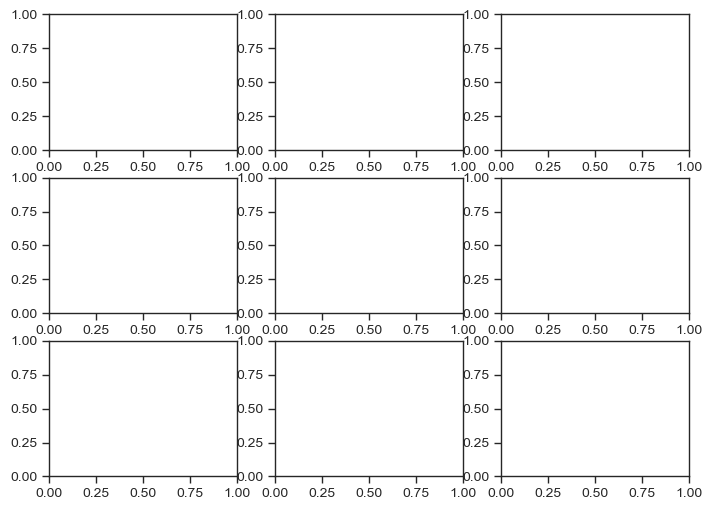

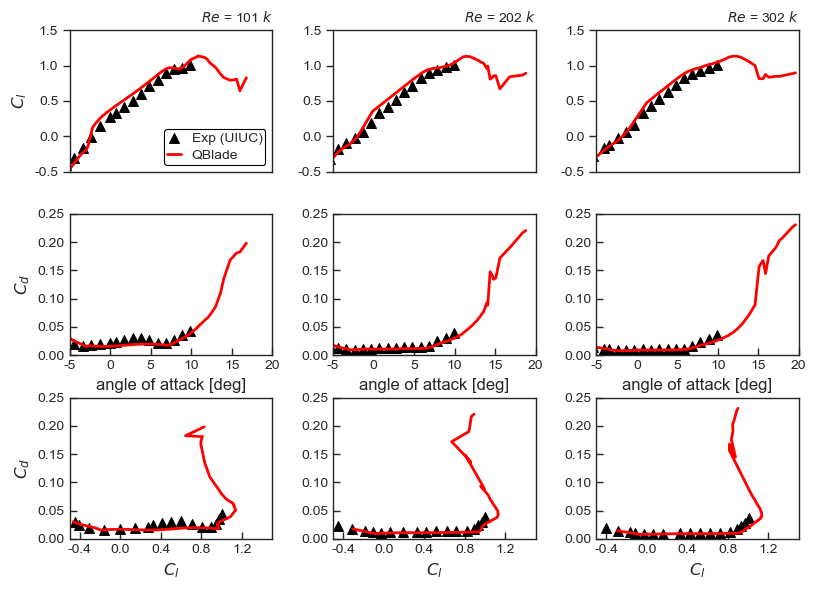

In [12]:
Re = 100900
airfoil = "E374"
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True


# create figure and axis objects
width, height = 2/3,2/3
figsize = (5.51  / width, 4 / height)
fig = plt.figure(figsize=figsize)
gs = GridSpec(nrows=3, ncols=3, figure=fig)
axs = []
axs.append(fig.add_subplot(gs[0, 0]))  # 第一行第一列
axs.append(fig.add_subplot(gs[0, 1]))  # 第一行第二列
axs.append(fig.add_subplot(gs[0, 2]))  # 第一行第三列

axs.append(fig.add_subplot(gs[1, 0]))  # 第二行第一列
axs.append(fig.add_subplot(gs[1, 1]))  # 第二行第二列
axs.append(fig.add_subplot(gs[1, 2]))  # 第二行第三列

axs.append(fig.add_subplot(gs[2, 0]))  # 第三行第一列
axs.append(fig.add_subplot(gs[2, 1]))  # 第三行第二列
axs.append(fig.add_subplot(gs[2, 2]))  # 第三行第三列

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=figsize)
curve_label = "Exp (UIUC)"
r, c = 0, 0
# plot the curve
axs[r,c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[r,c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[r,c].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[r,c].set_xlim(x_min, x_max)
axs[r,c].tick_params(axis='x', top=False)
axs[r,c].set_xticks([])
axs[r,c].set_ylim(y_min, y_max)

# set up the label of the axis
# axs[r,c].set_xlabel(x_label)
axs[r,c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[r,c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
# axs[r,c].xaxis.set_major_locator(MaxNLocator(nbins=5))  # 设置 x 轴的刻度数
axs[r,c].yaxis.set_major_locator(MaxNLocator(nbins=4))




c, r = 1, 0
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5)) 
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))




c, r = 2, 0
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))




Re = 201500
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x, y = 'alpha', 'Cl'
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True
r, c = 0, 1
# plot the curve
axs[r,c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[r,c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[r,c].set_title(r"$Re$ = 202 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[r,c].set_xlim(x_min, x_max)
axs[r,c].set_ylim(y_min, y_max)
axs[r,c].set_xticks([])
# set up the label of the axis
# axs[r,c].set_xlabel(x_label)
# axs[r,c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[0,0].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[r,c].yaxis.set_major_locator(MaxNLocator(nbins=4))



c, r = 1, 1
x, y = 'alpha', 'Cd'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )

axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  # 设置 x 轴的刻度数
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))


c, r = 2, 1
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))


Re = 302200
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 1.5
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True
r, c = 0, 2
# plot the curve
axs[r,c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[r,c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[r,c].set_title(r"$Re$ = 302 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[r,c].set_xlim(x_min, x_max)
axs[r,c].set_ylim(y_min, y_max)
axs[r,c].tick_params(axis='x', top=False)
axs[r,c].set_xticks([])
# set up the label of the axis
# axs[r,c].set_xlabel(x_label)
# axs[r,c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[0,0].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
        )
axs[r,c].yaxis.set_major_locator(MaxNLocator(nbins=4))



c, r = 1, 2
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.25
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )

axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  # 设置 x 轴的刻度数
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))


c, r = 2, 2
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 1.5
y_min,y_max = 0, 0.25
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))



plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)
# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )


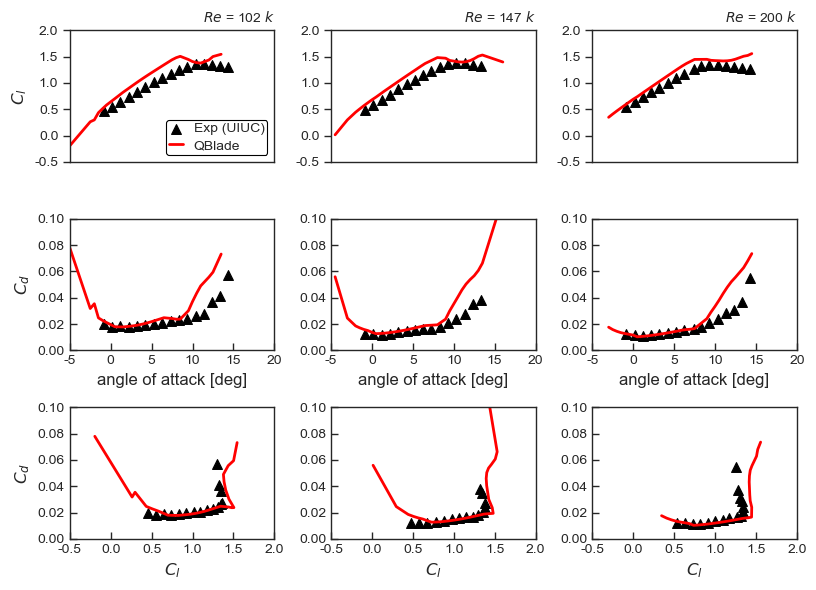

In [13]:
Re = 102600
airfoil = "NACA6409"
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 2
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True


# create figure and axis objects
width, height = 2/3,2/3
figsize = (5.51  / width, 4 / height)
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=figsize)
curve_label = "Exp (UIUC)"
r, c = 0, 0
# plot the curve
axs[r,c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[r,c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[r,c].set_title(r"$Re$ = 102 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[r,c].set_xlim(x_min, x_max)
axs[r,c].set_ylim(y_min, y_max)
axs[r,c].tick_params(axis='x', top=False)
axs[r,c].set_xticks([])
# set up the label of the axis
# axs[r,c].set_xlabel(x_label)
axs[r,c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[r,c].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[r,c].yaxis.set_major_locator(MaxNLocator(nbins=5))




c, r = 1, 0
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = -0.00, 0.1
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5)) 
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))




c, r = 2, 0
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 2.0
y_min,y_max = 0, 0.1
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True
# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))




Re = 147300
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x, y = 'alpha', 'Cl'
x_min, x_max = -5, 20
y_min,y_max = -0.5, 2
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True
r, c = 0, 1
# plot the curve
axs[r,c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[r,c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[r,c].set_title(r"$Re$ = 147 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[r,c].set_xlim(x_min, x_max)
axs[r,c].set_ylim(y_min, y_max)
axs[r,c].tick_params(axis='x', top=False)
axs[r,c].set_xticks([])
# set up the label of the axis
# axs[r,c].set_xlabel(x_label)
# axs[r,c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[0,0].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
        )
axs[r,c].yaxis.set_major_locator(MaxNLocator(nbins=5))



c, r = 1, 1
x, y = 'alpha', 'Cd'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = 0, 0.1
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )

axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  # 设置 x 轴的刻度数
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))


c, r = 2, 1
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 2.0
y_min,y_max = 0, 0.1
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))


Re = 200100
x, y = 'alpha', 'Cl'
data1 = extract_data(Experiment_data,airfoil_name=airfoil,Re=Re)
data2 = extract_data(Simulation_data,airfoil_name=airfoil,Re=Re)
x_min, x_max = -5, 20
y_min,y_max = -0.5, 2
x_label, y_label = r'angle of attack [deg]', r'$C_l$'
# legend_loc = None
legend_loc = True
r, c = 0, 2
# plot the curve
axs[r,c].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[r,c].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
axs[r,c].set_title(r"$Re$ = 200 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[r,c].set_xlim(x_min, x_max)
axs[r,c].set_ylim(y_min, y_max)
axs[r,c].tick_params(axis='x', top=False)
axs[r,c].set_xticks([])
# set up the label of the axis
# axs[r,c].set_xlabel(x_label)
# axs[r,c].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[0,0].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
        )
axs[r,c].yaxis.set_major_locator(MaxNLocator(nbins=5))



c, r = 1, 2
x, y = 'alpha', 'Cd'
x_min, x_max = -5, 20
y_min,y_max = 0, 0.1
x_label, y_label = r'angle of attack [deg]', r'$C_d$'
legend_loc = None
# legend_loc = True
fig_name = f"output/Re_{airfoil}.png"

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )

axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  # 设置 x 轴的刻度数
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))


c, r = 2, 2
x, y = 'Cl', 'Cd'
x_min, x_max = -0.5, 2.0
y_min,y_max = 0, 0.1
x_label, y_label = r'$C_l$', r'$C_d$'
legend_loc = None
# legend_loc = True

# plot the curve
axs[c,r].scatter(data1[x],data1[y],label = 'Exp (UIUC)',color='black',s=50,marker='^')
axs[c,r].plot(data2[x],data2[y],linestyle='-', color='red', label='QBlade')# '--' dotted line,'v' triangles# '--' dotted line,'v' triangles# using latex for curve label
# ax.set_title(r"$E$374, $Re =$ 101 $k$", fontsize=12)
# axs[c,r].set_title(r"$Re$ = 101 $k$", fontsize=10, loc='right')
# set axis labels and title
# set up the plot limits and labels
axs[c,r].set_xlim(x_min, x_max)
axs[c,r].set_ylim(y_min, y_max)
axs[c,r].tick_params(axis='both', direction='in', length=5)
# set up the label of the axis
axs[c,r].set_xlabel(x_label)
# axs[c,r].set_ylabel(y_label)
# legend status
if (legend_loc is not None):
        # set up the legend
        axs[c,r].legend(
        loc='lower right',
        framealpha=1, # transparency
        borderpad=0.2, # legend margins
        labelspacing=0.3, # tab spacing
        handlelength=1, # aspect ratio
        frameon=True,
        edgecolor='black' ,# Frame line colour
    )
axs[c,r].xaxis.set_major_locator(MaxNLocator(nbins=5))  
axs[c,r].yaxis.set_major_locator(MaxNLocator(nbins=5))



plt.tight_layout()
fig_name = f"output/{airfoil}.png"
# save the figure
plt.savefig(fig_name, 
            format='png', 
            bbox_inches='tight', 
            dpi=600
            )
